In [4]:
class TreeNode:
    def __init__(self, left = None , right=None):
        self.left=left
        self.right=right

relationship_status=TreeNode ("No", "Yes")
print(relationship_status)
print(relationship_status.left)
print(relationship_status.right)

age=TreeNode ("<18", ">18")
platform=TreeNode(age, relationship_status)

No
Yes


In [5]:
print(relationship_status)

In [8]:
print(platform, ":", platform.left, platform.right)
print(platform.left, ":", platform.left.left, platform.left.right)
print(platform.right, ":", platform.right.left, platform.right.right)

<__main__.TreeNode object at 0x0000022356D60D10> : <__main__.TreeNode object at 0x00000223547A1BB0> <__main__.TreeNode object at 0x0000022355A37140>
<__main__.TreeNode object at 0x00000223547A1BB0> : <18 >18
<__main__.TreeNode object at 0x0000022355A37140> : No Yes


In [3]:
from sklearn.cluster import KMeans
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
kmeans.labels_
kmeans.predict([[0, 0], [12, 3]])
kmeans.cluster_centers_

C:\Users\Lekhaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([[10.,  2.],
       [ 1.,  2.]])

In [5]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum(a - b) ** 2)

In [6]:
def knn_predict_class(X_train, y_train, x_query, k):
    distances = [(euclidean_distance(x_query, x_i), y_i) for x_i, y_i in zip(X_train, y_train)]
    distances.sort(key=lambda t: t[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return max(set(k_nearest_labels), key=k_nearest_labels.count)

def knn_predict_reg(X_train, y_train, x_query, k):
    distances = [(euclidean_distance(x_query, x_i), y_i) for x_i, y_i in zip(X_train, y_train)]
    distances.sort(key=lambda t: t[0])
    return np.mean([v for _, v in distances[:k]])

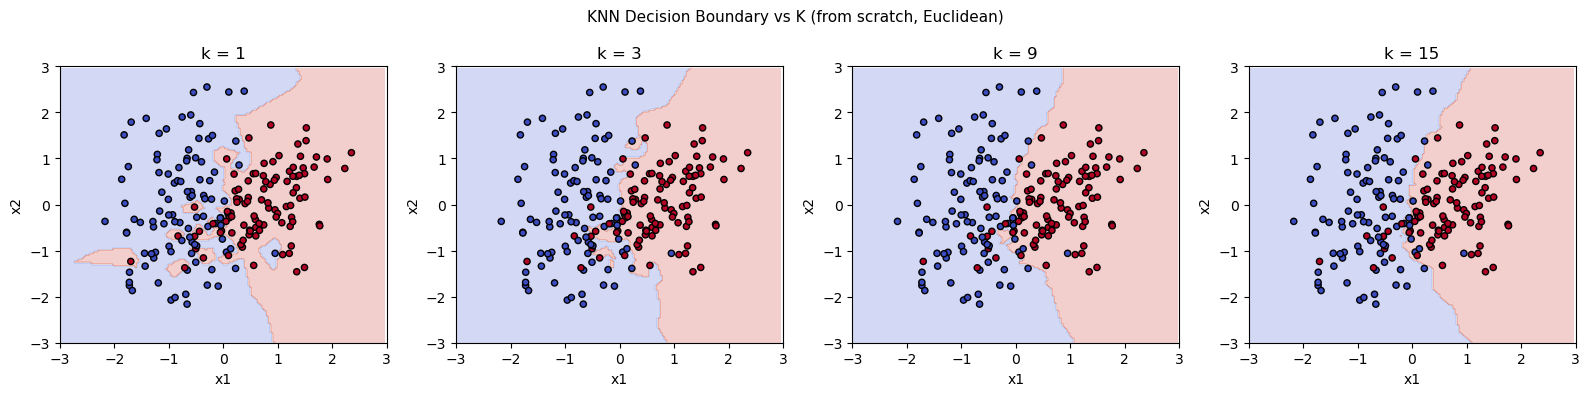

k=1 → highly irregular boundary (low bias, high variance)
k=15 → smoother boundary (higher bias, lower variance)


In [7]:
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                            n_redundant=0, n_clusters_per_class=1,
                            class_sep=1.2, random_state=42)
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

K_vals = [1, 3, 9, 15]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
h = 0.04
xx, yy = np.meshgrid(np.arange(-3, 3, h), np.arange(-3, 3, h))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, k in zip(axes, K_vals):
    # Vectorised prediction on grid (using from-scratch for pedagogy)
    dists = np.linalg.norm(X_s[:, None, :] - grid[None, :, :], axis=2)  # (n_train, n_grid)
    nn_idx = np.argsort(dists, axis=0)[:k]                               # (k, n_grid)
    votes = y[nn_idx]                                                      # (k, n_grid)
    Z = np.array([np.bincount(votes[:, i], minlength=2).argmax() for i in range(len(grid))])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.25)
    ax.scatter(X_s[:,0], X_s[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

plt.suptitle('KNN Decision Boundary vs K (from scratch, Euclidean)', fontsize=11)
plt.tight_layout()
plt.show()
print("k=1 → highly irregular boundary (low bias, high variance)")
print("k=15 → smoother boundary (higher bias, lower variance)")

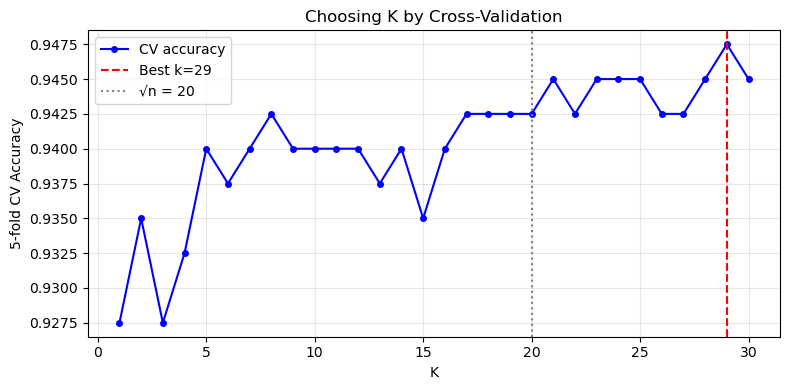

Best k = 29  CV accuracy = 0.9475
Rule-of-thumb k = √400 = 20


In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
X, y = make_classification(n_samples=400, n_features=2, n_informative=2,
                            n_redundant=0, class_sep=1.0, random_state=42)

k_range = range(1, 31)
cv_scores = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in k_range:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k))])
    sc = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy')
    cv_scores.append(sc.mean())

best_k = k_range[np.argmax(cv_scores)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), cv_scores, 'b-o', markersize=4, label='CV accuracy')
ax.axvline(best_k, color='r', linestyle='--', label=f'Best k={best_k}')
ax.axvline(int(np.sqrt(400)), color='gray', linestyle=':', label=f'√n = {int(np.sqrt(400))}')
ax.set_xlabel('K'); ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('Choosing K by Cross-Validation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Best k = {best_k}  CV accuracy = {max(cv_scores):.4f}")
print(f"Rule-of-thumb k = √400 = {int(np.sqrt(400))}")